# Basic approximation of distributions with `rJKOtt`

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

from rJKOtt import *


import numpy as np
from scipy.stats import uniform
import matplotlib.pyplot as plt

%matplotlib inline
import teneva



## Define the target distribution

In [2]:
calc_ode = False # use only fast sampling

In [3]:
N_comp = 5
dim = 2
L = 3.0  # Choose the bounds
N = [
    100,
] * dim  # Number of nodes in the grid; can be chosen independently in each direction, but we take uniforn
# means = uniform.rvs(loc=-L / 2, scale=L / 1, size=(N_comp, dim), random_state=1)
grid = Grid(-L, L, N, dim)  # Initialize the grid
scale = .1
theta = np.array(range(N_comp))*2.*np.pi/N_comp
r = 1.
means = np.ones((N_comp, dim)) * 2.
means[:, 0] += scale * r * np.cos(theta)
means[:, 1] += scale * r * np.sin(theta)

theta_rotation = theta / 5.
rotation_matrices = [np.array([[np.sin(t), np.cos(t)], [np.cos(t), -np.sin(t)]]) for t in theta_rotation]


cov_base = np.diag([2., 0.03])
# cov_base[[0, 1], [1, 0]] = -0.7
cov_base *= scale

covariance = [
    R.T @ cov_base @ R for R in rotation_matrices
] 
grid = Grid(-L, L, N, dim)  # Initialize the grid
gm = GaussianMixture(
    grid,
    means,
    covariance,
)  # Convenience class for Gaussian mixture (allows plotting)

Due to the structure of the the Gaussian mixture, we can plot it:

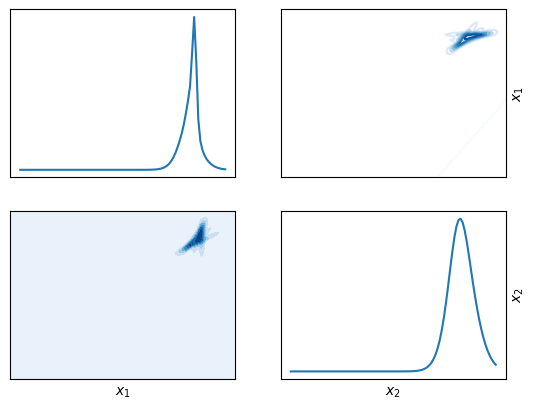

In [4]:
fig, axs = gm.plot_matrix_marginals(
    sym=True,
    contour_kwargs={
        "cmap": "Blues",
    },
    plot_kwargs={"color": "tab:blue", "label": r"$\rho_\infty$"},
)

Find the initial mean and covariance using Laplace approximation

In [5]:
m, Sigma, _ = TensorTrainSolver.get_preconditioning_laplace(lambda _x: gm.log_density(_x), np.zeros(dim))

/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/differentiate/_differentiate.py:564: RuntimeWarning: invalid value encountered in greater
  i = work.error < work.atol + work.rtol*abs(work.df)
/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/differentiate/_differentiate.py:564: RuntimeWarning: invalid value encountered in less
  i = work.error < work.atol + work.rtol*abs(work.df)
/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/differentiate/_differentiate.py:581: RuntimeWarning: invalid value encountered in greater
  i = (work.error > work.error_last*10) & ~stop


In [6]:
m, Sigma

(array([2.06037069, 2.11446272]),
 array([[0.01125663, 0.01359959],
        [0.01359959, 0.04686838]]))

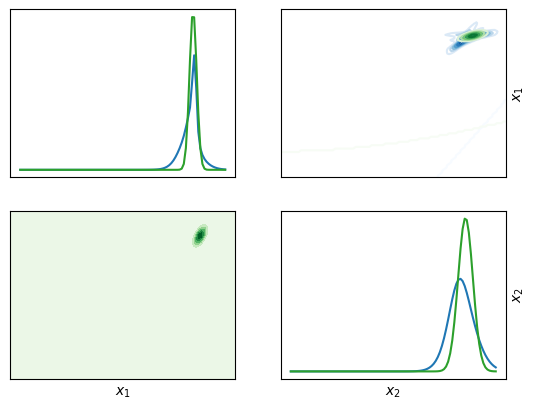

In [7]:
gm_laplace = GaussianMixture(grid, [m], [Sigma])

gm_laplace.plot_matrix_marginals(
    sym=True,
    axs=axs,
    contour_kwargs={
        "cmap": "Greens",
    },
    plot_kwargs={"color": "tab:green", "label": r"$\rho_L$"},
)
fig

### Define the initial TT approximation

In [8]:
tt_init = TensorTrainDistribution.gaussian(grid)

Let's plot the initial and the terminal distributions

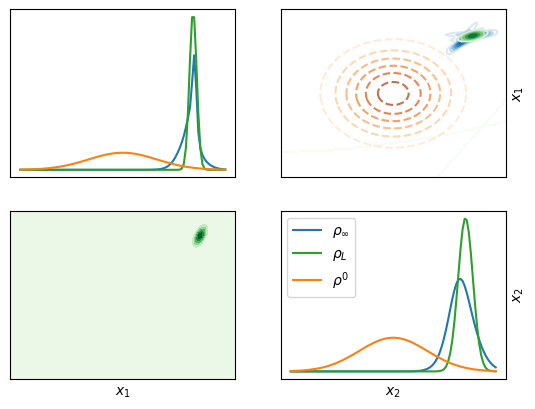

In [9]:
fig, axs = tt_init.plot_matrix_marginals(
    axs=axs,
    contour_kwargs={"cmap": "Oranges", "linestyles": "dashed", "alpha": 0.7},
    plot_kwargs={
        "color": "tab:orange",
        "label": r"$\rho^0$",
    },
)
axs[-1, -1].legend()
fig



### Initialize the solver

In [10]:
import rJKOtt.TensorTrainSolver

solver = TensorTrainSolver(
    gm.log_density,  # The function x -> rho_infty(x)
    tt_init,  # Info on the grid and the initial distribution (in TT)
    TensorTrainSolverParams(),  # Solver's parameters; for the most of them, defaults are OK
)

Initializing potentials...


### Set up the solver parameters

In [11]:
solver.params.max_rank = 5  # Max TT rank for all the represented variables
solver.params.cross_validation_rtol = 1e-8
# Early stopping criterion for the cross approximation
solver.params.fp_stopping_rtol = 1e-8
# Early stopping criterion for the fixed-point iterations. Set smaller in order to compute KL_est more accurately
solver.params.fp_relaxation = 1.0
# Relaxation factor for the fixed-point method. Default should be ok, make smaller if FP doesn't converge
solver.params.fp_method = '2_anderson'

### Run the solver
One timestep can be enough

In [12]:
_, rel_errors, _, _ = solver.step(1e-4, 1e5, save_history=True)

Initializing FP with method=2_anderson
	Solving initial condition  ranks= [ 1  9  1] dt=5.37e-03 n_calls=    5600 stop_condition='e'
	Rounding                   ranks= [ 1  1  1] dt=3.90e-04
	Solving terminal condition 

/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)
/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


ranks= [ 1 45  1] dt=7.84e-01 n_calls=  200000 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=1.96e-03
Starting FP step 1 rel_err inf
	Solving initial condition  ranks= [ 1  9  1] dt=8.92e-03 n_calls=    5600 stop_condition='e'
	Rounding                   ranks= [ 1  1  1] dt=5.70e-04
	Solving terminal condition ranks= [ 1 45  1] dt=6.64e-01 n_calls=  200000 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=1.53e-03
Starting FP step 2 rel_err 1.27e+02
	Solving initial condition  ranks= [ 1  5  1] dt=3.74e-03 n_calls=    2400 stop_condition='e'
	Rounding                   ranks= [ 1  3  1] dt=1.97e-04
	Solving terminal condition ranks= [ 1 45  1] dt=7.38e-01 n_calls=  200000 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=1.73e-03
Starting FP step 3 rel_err 2.25e-03
	Solving initial condition  ranks= [ 1  7  1] dt=5.19e-03 n_calls=    4000 stop_condition='e'
	Rounding                   ranks= [ 1  3  1] dt=4.07e-04
	Solving term

Display some diagnostic data about the convergence

KL error (w. posterior calls): nan
KL estimate (no posterior calls): -4.18e-06


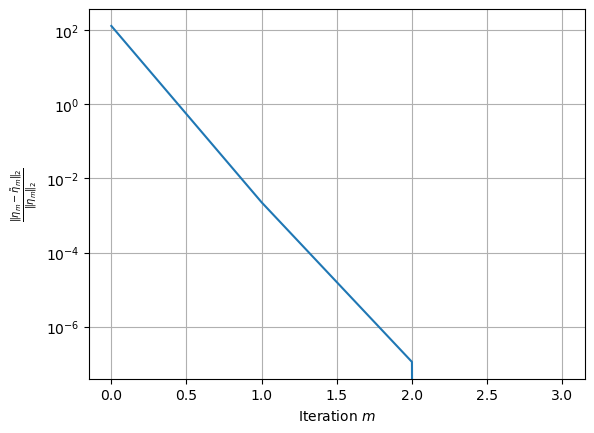

In [13]:
print(
    f"KL error (w. posterior calls): {solver.KLs[-1]:.2e}\nKL estimate (no posterior calls): {solver.KLs_est[-1]:.2e}"
)
plt.plot(rel_errors)
plt.yscale("log")
plt.ylabel(r"$\frac{\|\eta_m - \tilde\eta_m\|_2}{\|\eta_m\|_2}$")
plt.xlabel("Iteration $m$")
plt.grid(True)




## Sampling
The converged solver can be used to sample from the posterior.

In [14]:
x0 = np.random.randn(300, dim)

solver.params.sampling_sde_fraction = 1e-3
solver.params.sampling_n_euler_maruyama_steps = 50
if calc_ode:
    # sample by solving the ODE+SDE, samples the intial solution with TT method;
    # should work with arbitrary initialization
    sample_tt_ode1 = solver.sample(n_samples=300, method='ode', init_method='tt')
    # sample by solving the ODE+SDE, assumes initial samples have standard normal distribution;
    # (in the preconditioned coordinates)
    sample_tt_ode2 = solver.sample(n_samples=300, method='ode', init_method='normal')
# sample by TT method directly from the terminal TT distribution with refinement
# seems to be faster but samples could be worse
sample_tt_cond = solver.sample(n_samples=1000, method='tt')

In [15]:
sample_ref = gm.sample(1000)

### Results

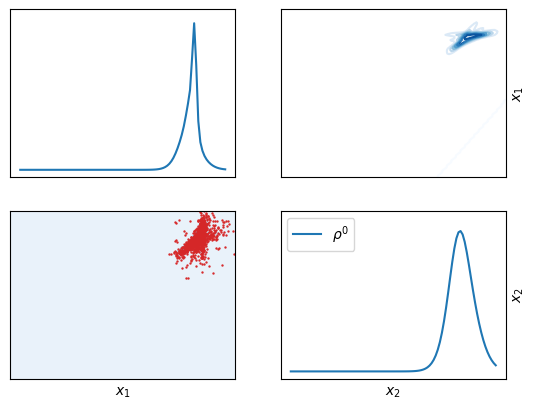

In [16]:
tt_final = solver.get_current_distribution()

fig, axs = gm.plot_matrix_marginals(
    param_subset=[0, 1, ],
    contour_kwargs={"cmap": "Blues", },
    plot_kwargs={
        "color": "tab:blue",
        "label": r"$\rho^0$",
    },
    sym=True,
)
if calc_ode:
    fig, axs = tt_final.plot_matrix_marginals(
        param_subset=[0, 1, ],
        axs=axs,
        contour_kwargs={"cmap": "Oranges", "linestyles": "dashed", "alpha": 0.5},
        plot_kwargs={
            "color": "tab:orange",
            "label": r"$\rho^{TT}$",
        },
        sym=True,
        scatter_kwargs={'color': 'tab:blue', 's': 1.3},
        sample=sample_tt_ode1
    )
    fig, axs = tt_final.plot_matrix_marginals(
        axs=axs,
        param_subset=[0, 1, ],
        contour_kwargs={"alpha": 0.0},
        plot_kwargs={"alpha": 0.0},
        scatter_kwargs={'color': 'tab:green', 's': 0.5, 'marker': '*', 'alpha': 1.},
        sample=sample_tt_ode2
    )
fig, axs = tt_final.plot_matrix_marginals(
    axs=axs,
    param_subset=[0, 1, ],
    contour_kwargs={"alpha": 0.0},
    plot_kwargs={"alpha": 0.0},
    scatter_kwargs={'color': 'tab:red', 's': 0.5, 'marker': 'o', 'alpha': 1.},
    sample=sample_tt_cond
)

axs[-1, -1].legend()

# Saving the state

In [17]:
solver.save_pickle("./solver_gm.pkl")

/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)
/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


# Preconditioned solve

In [18]:
import scipy as sp

grid_pc = Grid(-10., 10., [100]*dim, dim)
tt_pc_init = TensorTrainDistribution.gaussian(grid_pc)


solver_pc = TensorTrainSolver(gm.density, tt_pc_init, precondition_matrix=sp.linalg.sqrtm(Sigma), precondition_vector=m)

Initializing potentials...


In [19]:
solver_pc.params.max_rank = 5  # Max TT rank for all the represented variables
solver_pc.params.cross_validation_rtol = 1e-8
# Early stopping criterion for the cross approximation
solver_pc.params.fp_stopping_rtol = 1e-8
# Early stopping criterion for the fixed-point iterations. Set smaller in order to compute KL_est more accurately
solver_pc.params.fp_relaxation = 1.0
# Relaxation factor for the fixed-point method. Default should be ok, make smaller if FP doesn't converge
solver_pc.params.fp_method = '2_anderson'

### Run the solver
One timestep can be enough

In [20]:
_, rel_errors, _, _ = solver_pc.step(1e-2, 1e3, save_history=True)

Initializing FP with method=2_anderson
	Solving initial condition  ranks= [ 1  9  1] dt=7.01e-03 n_calls=    5600 stop_condition='e'
	Rounding                   ranks= [ 1  2  1] dt=4.99e-04
	Solving terminal condition 

/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)
/home/aksenov/miniconda3/envs/teneva_new/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


ranks= [ 1 57  1] dt=1.34e+00 n_calls=  322400 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=2.64e-03
Starting FP step 1 rel_err inf
	Solving initial condition  ranks= [ 1  9  1] dt=6.94e-03 n_calls=    5600 stop_condition='e'
	Rounding                   ranks= [ 1  2  1] dt=6.43e-04
	Solving terminal condition ranks= [ 1 47  1] dt=9.87e-01 n_calls=  218400 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=1.51e-03
Starting FP step 2 rel_err 4.01e+03
	Solving initial condition  ranks= [ 1  6  1] dt=5.33e-03 n_calls=    3200 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=9.93e-04
	Solving terminal condition ranks= [ 1 51  1] dt=1.03e+00 n_calls=  257600 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=2.13e-03
Starting FP step 3 rel_err 7.16e-02
	Solving initial condition  ranks= [ 1  9  1] dt=6.46e-03 n_calls=    5600 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=5.83e-04
	Solving term

In [21]:
sample_pc_tt = solver_pc.sample(3000, method='tt')
sample_tt_cond = solver.sample(3000, method='tt')
sample_ref = gm.sample(3000)

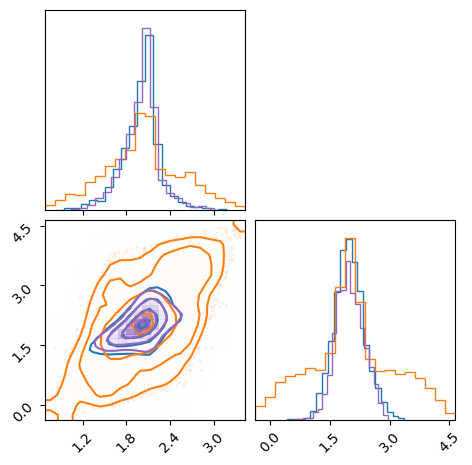

In [22]:
import corner

fig = corner.corner(sample_ref, color='tab:blue',  weights=np.ones(sample_ref.shape[0])/sample_ref.shape[0], group='Reference', smooth=1.)
fig = corner.corner(sample_pc_tt, color='tab:orange', fig=fig, weights=np.ones(sample_pc_tt.shape[0])/sample_pc_tt.shape[0], group='TT+PC', smooth=1.)
fig = corner.corner(sample_tt_cond, color='tab:purple', fig=fig, weights=np.ones(sample_tt_cond.shape[0])/sample_tt_cond.shape[0], group='TT', smooth=1.)


In [27]:
import ot

sample_ref_indep = gm.sample(3000)

ot.bregman.empirical_sinkhorn2_geomloss(sample_ref, sample_pc_tt, 1e-2),\
ot.bregman.empirical_sinkhorn2_geomloss(sample_ref, sample_tt_cond, 1e-2),\
ot.bregman.empirical_sinkhorn2_geomloss(sample_ref, sample_ref_indep, 1e-2)

(array(0.59120075), array(0.04276568), array(0.03571124))

# Re-using the solution in a perturbed problem
## Define perturbed posterior
Initial values can be taken from another solver (method `solver.reset_posterior`) or loaded from `.pkl` file (`TensorTrainSolver.load_pickle`). New posterior function has to be provided.

In [24]:
gm_perturbed = GaussianMixture(
    grid,
    means*1.2,
    [c * 0.9 for c in covariance],
) 

solver_perturbed = TensorTrainSolver.load_pickle("./solver_gm.pkl", gm_perturbed.density)

In [25]:
solver_perturbed.params.fp_method = 'Picard'
solver_perturbed.params.fp_relaxation = 1.0
_, rel_errors, _, _ = solver_perturbed.step(1e-4, 1e5, save_history=True)

Initializing FP with method=Picard
	Solving initial condition  ranks= [ 1  7  1] dt=1.08e-02 n_calls=    4000 stop_condition='e'
	Rounding                   ranks= [ 1  3  1] dt=3.66e-04
	Solving terminal condition ranks= [ 1 63  1] dt=1.42e+00 n_calls=  394400 stop_condition='m'
	Rounding                   ranks= [ 1  5  1] dt=4.05e-03
Starting FP step 1 rel_err inf
	Solving initial condition  ranks= [ 1  7  1] dt=1.44e-02 n_calls=    4000 stop_condition='e'
	Rounding                   ranks= [ 1  3  1] dt=9.26e-04
	Solving terminal condition ranks= [ 1 41  1] dt=7.08e-01 n_calls=  165600 stop_condition='e'
	Rounding                   ranks= [ 1  5  1] dt=2.07e-03
Starting FP step 2 rel_err 6.51e+00
	Solving initial condition  ranks= [ 1  7  1] dt=6.55e-03 n_calls=    4000 stop_condition='e'
	Rounding                   ranks= [ 1  4  1] dt=3.71e-04
	Solving terminal condition ranks= [ 1 37  1] dt=5.49e-01 n_calls=  134400 stop_condition='e'
	Rounding                   ranks= [ 1  5  1

(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: >, <Axes: ylabel='$x_{1}$'>],
        [<Axes: xlabel='$x_{1}$'>,
         <Axes: xlabel='$x_{2}$', ylabel='$x_{2}$'>]], dtype=object))

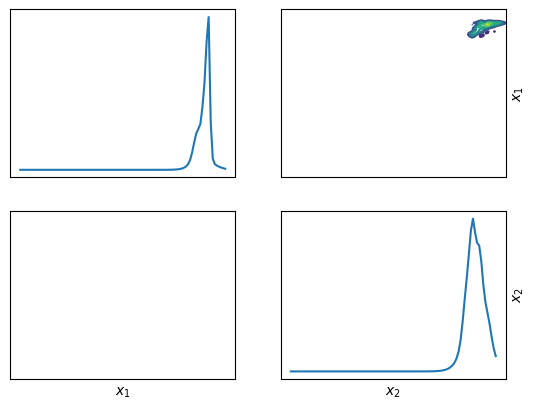

In [26]:
solver_perturbed.get_current_distribution().plot_matrix_marginals()

In [28]:
print(solver._C)

5.599254516897023
